In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
sales = pd.read_parquet('../data/processed/processed_data.parquet')

In [46]:
sales.info()
sales.head()

<class 'pandas.DataFrame'>
RangeIndex: 6098 entries, 0 to 6097
Columns: 1919 entries, id to d_1913
dtypes: int64(1913), str(6)
memory usage: 89.6 MB


,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


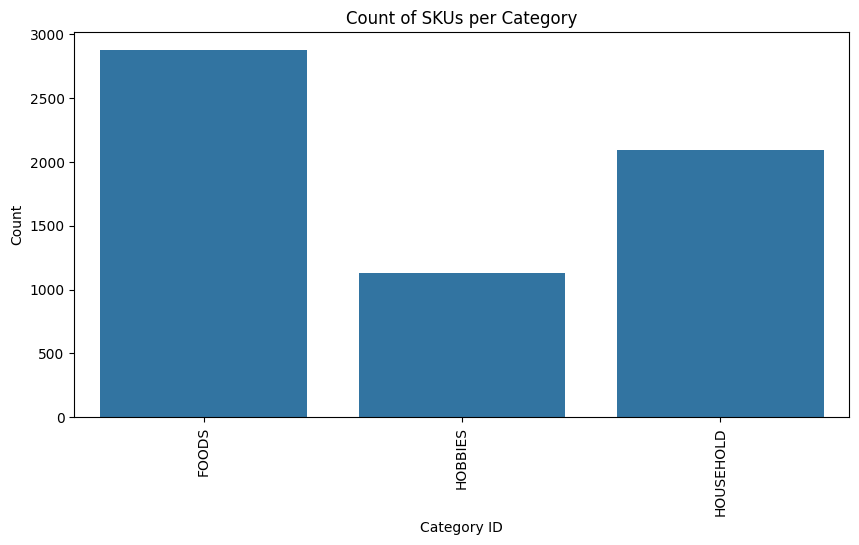

In [47]:
cat_id_diff_count = sales.groupby('cat_id')['cat_id'].count()
plt.figure(figsize=(10, 5))
sns.barplot(x=cat_id_diff_count.index, y=cat_id_diff_count.values)
plt.xticks(rotation=90)
plt.xlabel('Category ID')
plt.ylabel('Count')
plt.title('Count of SKUs per Category')
plt.show()


In [48]:
foods_sku = sales[sales['cat_id'] == 'FOODS'] 
foods_sku.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
1612,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,3,0,0,1,...,0,2,0,4,1,1,0,1,1,0
1613,FOODS_1_002_CA_1_validation,FOODS_1_002,FOODS_1,FOODS,CA_1,CA,0,1,0,1,...,1,3,1,0,0,1,2,0,0,0
1614,FOODS_1_003_CA_1_validation,FOODS_1_003,FOODS_1,FOODS,CA_1,CA,0,0,0,0,...,3,0,2,1,1,0,1,0,1,0
1615,FOODS_1_004_CA_1_validation,FOODS_1_004,FOODS_1,FOODS,CA_1,CA,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1616,FOODS_1_005_CA_1_validation,FOODS_1_005,FOODS_1,FOODS,CA_1,CA,3,9,3,3,...,3,1,1,2,0,2,2,1,4,1


In [49]:
dept_id_diff_count = foods_sku.groupby('dept_id')['dept_id'].count()
print(dept_id_diff_count)

dept_id
FOODS_1     432
FOODS_2     796
FOODS_3    1646
Name: dept_id, dtype: int64


In [50]:
foods_sku.shape

(2874, 1919)

In [51]:
sales.columns.nunique

<bound method IndexOpsMixin.nunique of Index(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1',
       'd_2', 'd_3', 'd_4',
       ...
       'd_1904', 'd_1905', 'd_1906', 'd_1907', 'd_1908', 'd_1909', 'd_1910',
       'd_1911', 'd_1912', 'd_1913'],
      dtype='str', length=1919)>

In [54]:
# Step 1: Melt the d_ columns to long format
melted_sales = pd.melt(
    foods_sku,
    id_vars=['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'],
    value_vars=[col for col in foods_sku.columns if col.startswith('d_')],
    var_name='d',
    value_name='daily_sales'
)

# Step 2: Group by item_id and calculate total sales
item_sales = melted_sales.groupby('item_id', as_index=False)['daily_sales'].sum().rename(columns={'daily_sales': 'total_sales'})

# Step 3: Sort by total sales descending and get top 50
top_50_items = item_sales.sort_values(by ='total_sales', ascending=False).head(50)

# If you want to keep all original columns for the top items:
# Merge the aggregated sales back with the original item information
unique_items = melted_sales.drop_duplicates('item_id').drop(columns=['d', 'daily_sales'])
final_result = pd.merge(top_50_items, unique_items, on='item_id')

# Reorder columns to put total_sales first
cols = ['item_id', 'total_sales'] + [col for col in final_result.columns if col not in ['item_id', 'total_sales']]
final_result = final_result[cols]


In [55]:
top_50_items.head(500)

,item_id,total_sales
702,FOODS_3_090,183372
1198,FOODS_3_586,151107
864,FOODS_3_252,132299
1325,FOODS_3_714,74842
732,FOODS_3_120,73743
1417,FOODS_3_808,71905
1199,FOODS_3_587,71408
1167,FOODS_3_555,68872
692,FOODS_3_080,67848
1153,FOODS_3_541,58287


Forcasting data 

In [56]:
forcasting_data = foods_sku.drop(columns=  ['id','cat_id', 'state_id'])

In [57]:
forcasting_data.head()

,item_id,dept_id,store_id,d_1,d_2,d_3,d_4,d_5,d_6,d_7,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
1612,FOODS_1_001,FOODS_1,CA_1,3,0,0,1,4,2,0,...,0,2,0,4,1,1,0,1,1,0
1613,FOODS_1_002,FOODS_1,CA_1,0,1,0,1,1,1,0,...,1,3,1,0,0,1,2,0,0,0
1614,FOODS_1_003,FOODS_1,CA_1,0,0,0,0,1,3,1,...,3,0,2,1,1,0,1,0,1,0
1615,FOODS_1_004,FOODS_1,CA_1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1616,FOODS_1_005,FOODS_1,CA_1,3,9,3,3,0,2,1,...,3,1,1,2,0,2,2,1,4,1


In [58]:
forcasting_data = forcasting_data[forcasting_data["item_id"].isin(top_50_items["item_id"])]

In [59]:
forcasting_data.to_csv("../data/clean/top_50_skus_forcasting.csv", index=False)

In [60]:
final_result = final_result.merge(item_sales, on='item_id', how = 'left')

In [61]:
final_result = final_result.drop(columns=["cat_id", "state_id"])

final_result.head(100)

,item_id,total_sales_x,id,dept_id,store_id,total_sales_y
0,FOODS_3_090,183372,FOODS_3_090_CA_1_validation,FOODS_3,CA_1,183372
1,FOODS_3_586,151107,FOODS_3_586_CA_1_validation,FOODS_3,CA_1,151107
2,FOODS_3_252,132299,FOODS_3_252_CA_1_validation,FOODS_3,CA_1,132299
3,FOODS_3_714,74842,FOODS_3_714_CA_1_validation,FOODS_3,CA_1,74842
4,FOODS_3_120,73743,FOODS_3_120_CA_1_validation,FOODS_3,CA_1,73743
5,FOODS_3_808,71905,FOODS_3_808_CA_1_validation,FOODS_3,CA_1,71905
6,FOODS_3_587,71408,FOODS_3_587_CA_1_validation,FOODS_3,CA_1,71408
7,FOODS_3_555,68872,FOODS_3_555_CA_1_validation,FOODS_3,CA_1,68872
8,FOODS_3_080,67848,FOODS_3_080_CA_1_validation,FOODS_3,CA_1,67848
9,FOODS_3_541,58287,FOODS_3_541_CA_1_validation,FOODS_3,CA_1,58287


In [62]:
final_result.to_csv("../data/clean/top_50_skus.csv", index=False)

In [ ]:
calendar = pd.read_parquet('../data/processed/calendar_subset.parquet')
top_50_skus_forcasting = pd.read_csv('../data/clean/top_50_skus_forcasting.csv')
calenda

,date,wm_yr_wk,d
0,2011-01-29,11101,d_1
1,2011-01-30,11101,d_2
2,2011-01-31,11101,d_3
3,2011-02-01,11101,d_4
4,2011-02-02,11101,d_5
...,...,...,...
1964,2016-06-15,11620,d_1965
1965,2016-06-16,11620,d_1966
1966,2016-06-17,11620,d_1967
1967,2016-06-18,11621,d_1968


In [68]:
top_50_skus_forcasting = pd.melt(
    top_50_skus_forcasting,
    id_vars=['item_id', 'dept_id','store_id',],
    value_vars=[col for col in foods_sku.columns if col.startswith('d_')],
    var_name='d',
    value_name='daily_sales'
)

In [69]:
top_50_skus_forcasting


,item_id,dept_id,store_id,d,daily_sales
0,FOODS_1_018,FOODS_1,CA_1,d_1,17
1,FOODS_1_085,FOODS_1,CA_1,d_1,10
2,FOODS_1_161,FOODS_1,CA_1,d_1,4
3,FOODS_1_218,FOODS_1,CA_1,d_1,10
4,FOODS_2_019,FOODS_2,CA_1,d_1,15
...,...,...,...,...,...
191295,FOODS_3_755,FOODS_3,CA_2,d_1913,13
191296,FOODS_3_764,FOODS_3,CA_2,d_1913,12
191297,FOODS_3_785,FOODS_3,CA_2,d_1913,14
191298,FOODS_3_804,FOODS_3,CA_2,d_1913,20


In [70]:
weekly_demand = top_50_skus_forcasting.merge(calendar, on='d', how='left')

In [71]:
weekly_demand 

,item_id,dept_id,store_id,d,daily_sales,date,wm_yr_wk
0,FOODS_1_018,FOODS_1,CA_1,d_1,17,2011-01-29,11101
1,FOODS_1_085,FOODS_1,CA_1,d_1,10,2011-01-29,11101
2,FOODS_1_161,FOODS_1,CA_1,d_1,4,2011-01-29,11101
3,FOODS_1_218,FOODS_1,CA_1,d_1,10,2011-01-29,11101
4,FOODS_2_019,FOODS_2,CA_1,d_1,15,2011-01-29,11101
...,...,...,...,...,...,...,...
191295,FOODS_3_755,FOODS_3,CA_2,d_1913,13,2016-04-24,11613
191296,FOODS_3_764,FOODS_3,CA_2,d_1913,12,2016-04-24,11613
191297,FOODS_3_785,FOODS_3,CA_2,d_1913,14,2016-04-24,11613
191298,FOODS_3_804,FOODS_3,CA_2,d_1913,20,2016-04-24,11613


In [75]:
weekly_demand = weekly_demand.groupby(['item_id','store_id','wm_yr_wk']).agg({'daily_sales': 'sum'}).reset_index()
weekly_demand_rename_daily_sales = weekly_demand.rename(columns={'daily_sales': 'weekly_sales'})
weekly_demand_rename_daily_sales.to_csv("../data/chainos.db/top_50_skus_forcasting.csv", index=False)
